# Chapter 4 Project: Clustering Robot Vibration Data

Part of the ML for Robotics course
https://purwar-lab.github.io/ml-for-robotics-

Run cells top to bottom. Each cell is one step of the
unsupervised learning pipeline.

**Cell 1: Kaggle download** - This cell installs the Kaggle library and uses your API token to download the vibration dataset directly into Colab.

In [2]:
!pip -q install kaggle
import json
import os
from getpass import getpass

os.makedirs("/root/.kaggle", exist_ok=True)
token = json.loads(getpass("Paste your Kaggle API token text: ").strip())
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(token, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)
!kaggle datasets download -d jishnukoliyadan/vibration-analysis-on-rotating-shaft
!unzip -o vibration-analysis-on-rotating-shaft.zip -d vibration_data

Paste your Kaggle API token text: ··········
Dataset URL: https://www.kaggle.com/datasets/jishnukoliyadan/vibration-analysis-on-rotating-shaft
License(s): Attribution 4.0 International (CC BY 4.0)
100% 2.62G/2.62G [00:31<00:00, 90.4MB/s]

Archive:  vibration-analysis-on-rotating-shaft.zip
  inflating: vibration_data/0D.csv   
  inflating: vibration_data/0E.csv   
  inflating: vibration_data/1D.csv   
  inflating: vibration_data/1E.csv   
  inflating: vibration_data/2D.csv   
  inflating: vibration_data/2E.csv   
  inflating: vibration_data/3D.csv   
  inflating: vibration_data/3E.csv   
  inflating: vibration_data/4D.csv   
  inflating: vibration_data/4E.csv   


**Cell 2: Load data** - Load the downloaded CSV, or generate synthetic vibration data automatically if the download failed — the analysis works either way.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

files = list(Path("vibration_data").glob("*.csv"))
if files:
    df = pd.read_csv(files[0])
else:
    t = np.linspace(0, 60, 6000)
    normal = np.sin(2 * np.pi * 10 * t[:2000]) * 0.5
    imbalanced = np.sin(2 * np.pi * 18 * t[:2000]) * 1.2
    loose = np.sin(2 * np.pi * 10 * t[:2000]) + 0.4 * np.sin(2 * np.pi * 45 * t[:2000])
    signal = np.r_[normal, imbalanced, loose]
    df = pd.DataFrame({"time": t, "vibration": signal})

display(df.head())
print(df.shape)

,V_in,Measured_RPM,Vibration_1,Vibration_2,Vibration_3
0,0.0,28.610235,0.0,0.0,0.0
1,0.0,28.610235,0.0,0.0,0.0
2,0.0,28.610235,0.0,0.0,0.0
3,0.0,28.610235,0.0,0.0,0.0
4,0.0,28.610235,0.0,0.0,0.0


(6893567, 5)


**Cell 3: Plot signal** - Plot the raw signal before processing anything — a flat line or missing data shows up immediately in a waveform plot.

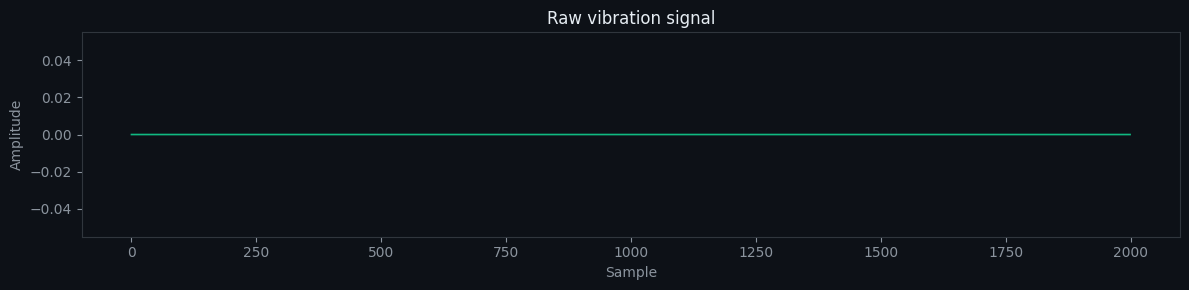

In [4]:
signal_col = "vibration" if "vibration" in df.columns else df.select_dtypes("number").columns[-1]

fig, ax = plt.subplots(figsize=(12, 3))
fig.patch.set_facecolor('#0d1117')
ax.plot(df[signal_col].values[:2000], color='#10b981', linewidth=1.2)
ax.set_title("Raw vibration signal", color='#e6edf3')
ax.set_xlabel("Sample", color='#8b949e')
ax.set_ylabel("Amplitude", color='#8b949e')
ax.set_facecolor('#0d1117')
ax.tick_params(colors='#8b949e')
ax.spines[:].set_color('#30363d')
plt.tight_layout()
plt.show()

**Cell 4: Feature engineering** - K-Means works on numbers, not raw waves — this cell extracts four statistical features from each 256-sample window.

In [5]:
values = df[signal_col].dropna().to_numpy()
window = 256
features = []

for start in range(0, len(values) - window, window):
    chunk = values[start:start + window]
    fft = np.abs(np.fft.rfft(chunk))
    features.append({
        "mean": chunk.mean(),
        "std": chunk.std(),
        "max": chunk.max(),
        "fft_peak": fft[1:].argmax() + 1
    })

feature_df = pd.DataFrame(features)
display(feature_df.head())

,mean,std,max,fft_peak
0,0.000000e+00,0.0,0.000000e+00,1
1,2.537405e-314,0.0,6.495757e-312,2
2,0.000000e+00,0.0,0.000000e+00,1
3,0.000000e+00,0.0,0.000000e+00,1
4,0.000000e+00,0.0,0.000000e+00,1


**Cell 5: Scale features** - Scale features to equal ranges so K-Means does not ignore small-valued columns when computing distances.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_df)

**Cell 6: Elbow method** - Run K-Means for K=1 through 10 and plot the inertia to find the natural number of clusters in the data.

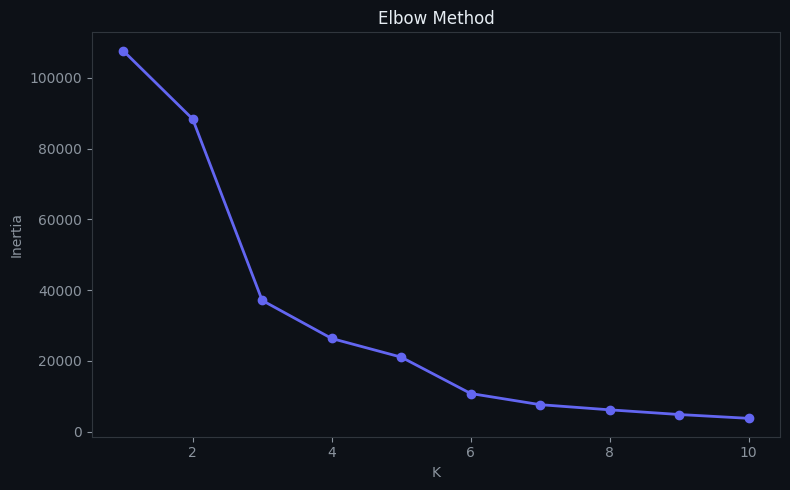

In [7]:
from sklearn.cluster import KMeans

ks = range(1, 11)
inertias = []
for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#0d1117')
ax.plot(list(ks), inertias, marker="o", color='#6366f1', linewidth=2)
ax.set_xlabel("K", color='#8b949e')
ax.set_ylabel("Inertia", color='#8b949e')
ax.set_title("Elbow Method", color='#e6edf3')
ax.set_facecolor('#0d1117')
ax.tick_params(colors='#8b949e')
ax.spines[:].set_color('#30363d')
plt.tight_layout()
plt.show()

**Cell 7: Fit K-Means** - Fit K-Means with K=3 and assign every window to a cluster — then look at the average feature values per cluster.

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(X_scaled)
feature_df["cluster"] = cluster_labels
display(feature_df.groupby("cluster").mean())

,mean,std,max,fft_peak
cluster,,,,
0,0.006832,0.002331,0.013525,12.070343
1,0.003351,0.001825,0.009319,62.241508
2,4.015817,0.110224,4.589060,2.000000


**Cell 8: PCA scatter** - Compress the four-feature space into two dimensions with PCA so the clusters can be visualized on a scatter plot.

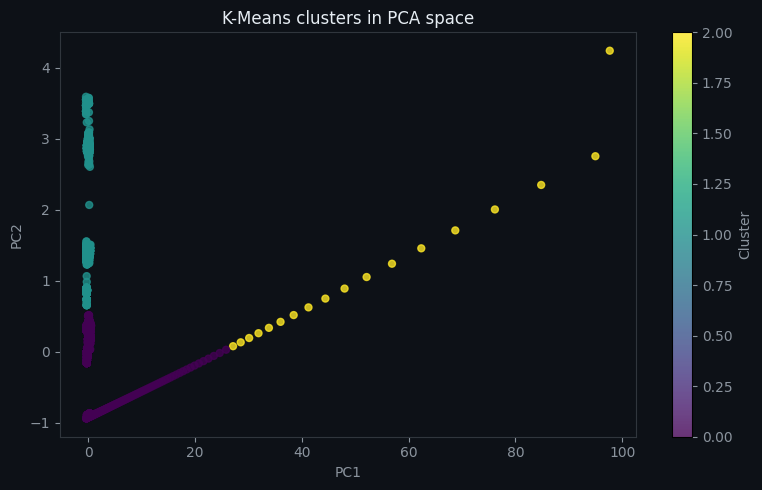

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
points_2d = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#0d1117')
scatter = ax.scatter(points_2d[:, 0], points_2d[:, 1],
                     c=cluster_labels, cmap="viridis", s=25, alpha=0.8)
ax.set_xlabel("PC1", color='#8b949e')
ax.set_ylabel("PC2", color='#8b949e')
ax.set_title("K-Means clusters in PCA space", color='#e6edf3')
ax.set_facecolor('#0d1117')
ax.tick_params(colors='#8b949e')
ax.spines[:].set_color('#30363d')
cbar = plt.colorbar(scatter, label="Cluster")
cbar.ax.yaxis.label.set_color('#8b949e')
cbar.ax.tick_params(colors='#8b949e')
plt.tight_layout()
plt.show()

**Cell 9: Interpret clusters** - Print the mean and standard deviation of each feature per cluster so you can give each cluster an engineering label.

In [10]:
summary = feature_df.groupby("cluster").agg(["mean", "std"])
display(summary)

for cluster_id, row in feature_df.groupby("cluster").mean().iterrows():
    print(f"Cluster {cluster_id}: std={row['std']:.3f}, fft_peak={row['fft_peak']:.1f}")

mean                 std                 max            \
             mean       std      mean       std      mean       std   
cluster                                                               
0        0.006832  0.065087  0.002331  0.001198  0.013525  0.065983   
1        0.003351  0.002033  0.001825  0.001283  0.009319  0.004405   
2        4.015817  1.733549  0.110224  0.106194  4.589060  1.700097   

          fft_peak             
              mean        std  
cluster                        
0        12.070343  12.650723  
1        62.241508  11.884661  
2         2.000000   4.242641

Cluster 0: std=0.002, fft_peak=12.1
Cluster 1: std=0.002, fft_peak=62.2
Cluster 2: std=0.110, fft_peak=2.0


**Cell 10: DBSCAN** - Try DBSCAN as an alternative — it finds clusters without needing K specified in advance and marks outliers as -1.

Running DBSCAN on 5000 points out of 26927 total points.
DBSCAN label counts:
Noise/outliers: 13
Cluster 0: 4849
Cluster 1: 138


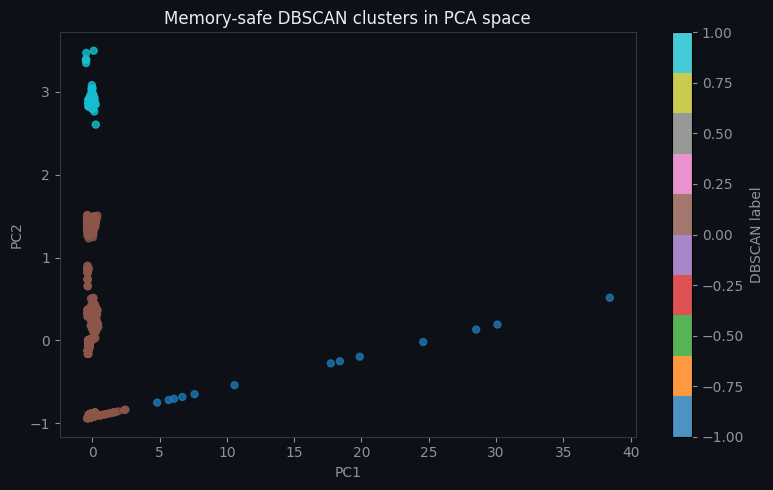

In [11]:
# Cell 10: Memory-safe DBSCAN
# DBSCAN can run out of RAM on large datasets because it may build many neighbor relationships.
# This version runs DBSCAN on a manageable subset and plots that subset in PCA space.

from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Choose a maximum number of points for DBSCAN
# ------------------------------------------------------------
max_dbscan_points = 5000   # Increase to 10000 if Colab has enough RAM

n_points = X_scaled.shape[0]

if n_points > max_dbscan_points:
    rng = np.random.default_rng(42)
    db_idx = rng.choice(n_points, size=max_dbscan_points, replace=False)
    X_db = X_scaled[db_idx]
    points_2d_db = points_2d[db_idx]
else:
    db_idx = np.arange(n_points)
    X_db = X_scaled
    points_2d_db = points_2d

print(f"Running DBSCAN on {X_db.shape[0]} points out of {n_points} total points.")

# ------------------------------------------------------------
# 2. Fit DBSCAN on the subset
# ------------------------------------------------------------
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5,
    algorithm="kd_tree",   # usually more memory-friendly for low-dimensional data
    n_jobs=1               # avoids extra memory use from parallel workers
)

db_labels = dbscan.fit_predict(X_db)

# ------------------------------------------------------------
# 3. Report cluster information
# ------------------------------------------------------------
unique_labels, counts = np.unique(db_labels, return_counts=True)

print("DBSCAN label counts:")
for label, count in zip(unique_labels, counts):
    if label == -1:
        print(f"Noise/outliers: {count}")
    else:
        print(f"Cluster {label}: {count}")

# ------------------------------------------------------------
# 4. Plot DBSCAN result in PCA space
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#0d1117')

scatter = ax.scatter(
    points_2d_db[:, 0],
    points_2d_db[:, 1],
    c=db_labels,
    cmap="tab10",
    s=25,
    alpha=0.8
)

ax.set_title("Memory-safe DBSCAN clusters in PCA space", color='#e6edf3')
ax.set_xlabel("PC1", color='#8b949e')
ax.set_ylabel("PC2", color='#8b949e')
ax.set_facecolor('#0d1117')
ax.tick_params(colors='#8b949e')
ax.spines[:].set_color('#30363d')

cbar = plt.colorbar(scatter, label="DBSCAN label")
cbar.ax.yaxis.label.set_color('#8b949e')
cbar.ax.tick_params(colors='#8b949e')

plt.tight_layout()
plt.show()

## What's next?
Return to the course page to complete the lesson and mark it as done.